In [2]:
import subprocess
import sys

# Instalar paquetes necesarios
packages = ['torch', 'torchvision', 'numpy', 'matplotlib', 'seaborn', 'scikit-learn', 'pillow']
for package in packages:
    try:
        __import__(package)
    except ImportError:
        print(f'Instalando {package}...')
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', package])
        print(f'{package} instalado.')

print(' Todos los paquetes están listos.')

Instalando scikit-learn...
scikit-learn instalado.
Instalando pillow...
pillow instalado.
 Todos los paquetes están listos.


# ETL — Objetivo 1
**Datasets:** Chest X-Ray (Pneumonia) · IQ-OTH/NCCD Lung Cancer  
**Protocolo:** resize 128×128 · normalización ImageNet · augmentation · split estratificado 70/15/15 · seed=42


In [3]:
import os, random, shutil, json
from pathlib import Path
from collections import Counter

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torchvision.transforms as T
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader, WeightedRandomSampler
from sklearn.model_selection import train_test_split

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

print('Torch:', torch.__version__)
print('CUDA:', torch.cuda.is_available())
if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))

Torch: 2.12.0+cpu
CUDA: False


## Configuración de rutas

In [4]:
BASE_DIR   = Path(os.getcwd())

CHEST_DIR  = BASE_DIR / 'dataset' / 'chest_xray' / 'chest_xray'
LUNG_DIR   = BASE_DIR / 'dataset' / 'The IQ-OTHNCCD lung cancer dataset'
OUTPUT_DIR = BASE_DIR / 'etl_output'

CHEST_OUT  = OUTPUT_DIR / 'chest_xray'
LUNG_OUT   = OUTPUT_DIR / 'lung_cancer'

IMG_SIZE   = (128, 128)
BATCH_SIZE = 32

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

print('Chest  :', CHEST_DIR.exists(), CHEST_DIR)
print('Lung   :', LUNG_DIR.exists(),  LUNG_DIR)
print('Output :', OUTPUT_DIR)

Chest  : True D:\CURSOS 2026 - 1\Cyberseguridad\jupyterlab\investigacion\dataset\chest_xray\chest_xray
Lung   : True D:\CURSOS 2026 - 1\Cyberseguridad\jupyterlab\investigacion\dataset\The IQ-OTHNCCD lung cancer dataset
Output : D:\CURSOS 2026 - 1\Cyberseguridad\jupyterlab\investigacion\etl_output


## 1 · Extracción

In [5]:
EXTS = {'.jpg', '.jpeg', '.png'}

def collect_images(root, label_map=None):
    records = []
    for cls_dir in sorted(Path(root).iterdir()):
        if not cls_dir.is_dir():
            continue
        label = cls_dir.name
        if label_map:
            label = label_map.get(label, label)
        for img_path in cls_dir.iterdir():
            if img_path.suffix.lower() in EXTS:
                records.append({'path': img_path, 'label': label})
    return records

# Chest X-Ray: unir los 3 splits originales (val original solo tiene 8 por clase)
chest_all = []
for split in ['train', 'val', 'test']:
    sp = CHEST_DIR / split
    if sp.exists():
        chest_all.extend(collect_images(sp))

# Lung Cancer: renombrar carpetas a etiquetas limpias
LUNG_MAP = {
    'Bengin cases':    'Benign',
    'Malignant cases': 'Malignant',
    'Normal cases':    'Normal',
}
lung_all = collect_images(LUNG_DIR, label_map=LUNG_MAP)

print('=== Chest X-Ray (reunido) ===')
for cls, n in Counter(r['label'] for r in chest_all).items():
    print(f'  {cls}: {n}')
print(f'  TOTAL: {len(chest_all)}')

print('\n=== IQ-OTH/NCCD Lung Cancer ===')
for cls, n in Counter(r['label'] for r in lung_all).items():
    print(f'  {cls}: {n}')
print(f'  TOTAL: {len(lung_all)}')

=== Chest X-Ray (reunido) ===
  NORMAL: 1583
  PNEUMONIA: 4273
  TOTAL: 5856

=== IQ-OTH/NCCD Lung Cancer ===
  Benign: 120
  Malignant: 561
  Normal: 416
  TOTAL: 1097


## 2 · Transformación — transforms

In [6]:
transform_train = T.Compose([
    T.Resize(IMG_SIZE),
    T.Grayscale(num_output_channels=3),   # CXR es gris → 3 canales para ResNet
    T.RandomRotation(degrees=10),
    T.RandomHorizontalFlip(),
    T.ColorJitter(brightness=0.15),
    T.RandomAffine(degrees=0, scale=(0.90, 1.10)),   # zoom ±10%
    T.ToTensor(),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

transform_eval = T.Compose([
    T.Resize(IMG_SIZE),
    T.Grayscale(num_output_channels=3),
    T.ToTensor(),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

print('transform_train:', transform_train)
print('transform_eval: ', transform_eval)

transform_train: Compose(
    Resize(size=(128, 128), interpolation=bilinear, max_size=None, antialias=True)
    Grayscale(num_output_channels=3)
    RandomRotation(degrees=[-10.0, 10.0], interpolation=nearest, expand=False, fill=0)
    RandomHorizontalFlip(p=0.5)
    ColorJitter(brightness=(0.85, 1.15), contrast=None, saturation=None, hue=None)
    RandomAffine(degrees=[0.0, 0.0], scale=(0.9, 1.1))
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)
transform_eval:  Compose(
    Resize(size=(128, 128), interpolation=bilinear, max_size=None, antialias=True)
    Grayscale(num_output_channels=3)
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)


## 3 · Split estratificado 70 / 15 / 15

In [7]:
def stratified_split(records, seed=42):
    paths  = [r['path']  for r in records]
    labels = [r['label'] for r in records]

    p_train, p_tmp, l_train, l_tmp = train_test_split(
        paths, labels, test_size=0.30, stratify=labels, random_state=seed
    )
    p_val, p_test, l_val, l_test = train_test_split(
        p_tmp, l_tmp, test_size=0.50, stratify=l_tmp, random_state=seed
    )
    return (
        list(zip(p_train, l_train)),
        list(zip(p_val,   l_val)),
        list(zip(p_test,  l_test)),
    )

chest_train, chest_val, chest_test = stratified_split(chest_all)
lung_train,  lung_val,  lung_test  = stratified_split(lung_all)

def print_split(name, train, val, test):
    total = len(train) + len(val) + len(test)
    print(f'\n=== {name} ===')
    for sname, split in [('train', train), ('val', val), ('test', test)]:
        cc = dict(Counter(l for _, l in split))
        print(f'  {sname:5s}: {len(split):4d} ({len(split)/total*100:.1f}%)  {cc}')

print_split('Chest X-Ray', chest_train, chest_val, chest_test)
print_split('Lung Cancer',  lung_train,  lung_val,  lung_test)


=== Chest X-Ray ===
  train: 4099 (70.0%)  {'PNEUMONIA': 2991, 'NORMAL': 1108}
  val  :  878 (15.0%)  {'NORMAL': 237, 'PNEUMONIA': 641}
  test :  879 (15.0%)  {'PNEUMONIA': 641, 'NORMAL': 238}

=== Lung Cancer ===
  train:  767 (69.9%)  {'Benign': 84, 'Malignant': 392, 'Normal': 291}
  val  :  165 (15.0%)  {'Malignant': 84, 'Normal': 63, 'Benign': 18}
  test :  165 (15.0%)  {'Malignant': 85, 'Normal': 62, 'Benign': 18}


## 4 · Carga — copiar imágenes a etl_output/

In [8]:
def copy_split(split_list, dest_dir):
    dest_dir = Path(dest_dir)
    dest_dir.mkdir(parents=True, exist_ok=True)
    manifest = []
    for src_path, label in split_list:
        label_dir = dest_dir / label
        label_dir.mkdir(exist_ok=True)
        dst = label_dir / Path(src_path).name
        if dst.exists():
            stem, suffix, c = dst.stem, dst.suffix, 1
            while dst.exists():
                dst = label_dir / f'{stem}_{c}{suffix}'
                c += 1
        shutil.copy2(src_path, dst)
        manifest.append({'path': str(dst.relative_to(OUTPUT_DIR)), 'label': label})
    return manifest

def save_dataset(name, out_root, train, val, test):
    out_root = Path(out_root)
    print(f'Copiando {name}...')
    m = {
        'train': copy_split(train, out_root / 'train'),
        'val':   copy_split(val,   out_root / 'val'),
        'test':  copy_split(test,  out_root / 'test'),
    }
    meta = {
        'seed': SEED, 'img_size': IMG_SIZE,
        'split_ratio': '70/15/15',
        'splits': {k: len(v) for k, v in m.items()},
        'files': m,
    }
    with open(out_root / 'manifest.json', 'w') as f:
        json.dump(meta, f, indent=2)
    print(f'  {name}: train={len(m["train"])} val={len(m["val"])} test={len(m["test"])}')

save_dataset('Chest X-Ray', CHEST_OUT, chest_train, chest_val, chest_test)
save_dataset('Lung Cancer',  LUNG_OUT,  lung_train,  lung_val,  lung_test)
print('\nETL completo. Archivos en:', OUTPUT_DIR)

Copiando Chest X-Ray...
  Chest X-Ray: train=4099 val=878 test=879
Copiando Lung Cancer...
  Lung Cancer: train=767 val=165 test=165

ETL completo. Archivos en: D:\CURSOS 2026 - 1\Cyberseguridad\jupyterlab\investigacion\etl_output


## 5 · DataLoaders para entrenamiento

In [9]:
def make_loaders(out_root, batch_size=BATCH_SIZE, weighted_sampler=False):
    out_root = Path(out_root)
    ds_train = ImageFolder(out_root / 'train', transform=transform_train)
    ds_val   = ImageFolder(out_root / 'val',   transform=transform_eval)
    ds_test  = ImageFolder(out_root / 'test',  transform=transform_eval)

    if weighted_sampler:
        targets = torch.tensor(ds_train.targets)
        cw = 1.0 / torch.bincount(targets).float()
        sw = cw[targets]
        sampler = WeightedRandomSampler(sw, num_samples=len(sw), replacement=True)
        loader_train = DataLoader(ds_train, batch_size=batch_size, sampler=sampler,
                                  num_workers=2, pin_memory=True)
    else:
        loader_train = DataLoader(ds_train, batch_size=batch_size, shuffle=True,
                                  num_workers=2, pin_memory=True)

    loader_val  = DataLoader(ds_val,  batch_size=batch_size, shuffle=False,
                             num_workers=2, pin_memory=True)
    loader_test = DataLoader(ds_test, batch_size=batch_size, shuffle=False,
                             num_workers=2, pin_memory=True)

    return loader_train, loader_val, loader_test, ds_train.class_to_idx

chest_train_loader, chest_val_loader, chest_test_loader, chest_classes = make_loaders(CHEST_OUT)
lung_train_loader,  lung_val_loader,  lung_test_loader,  lung_classes  = make_loaders(
    LUNG_OUT, weighted_sampler=True
)

print('Chest classes:', chest_classes)
print('Lung classes: ', lung_classes)

Chest classes: {'NORMAL': 0, 'PNEUMONIA': 1}
Lung classes:  {'Benign': 0, 'Malignant': 1, 'Normal': 2}


## 6 · Verificación visual y distribución de clases

D:\CURSOS 2026 - 1\Cyberseguridad\jupyterlab\envprueba\Lib\site-packages\torch\utils\data\dataloader.py:1095: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


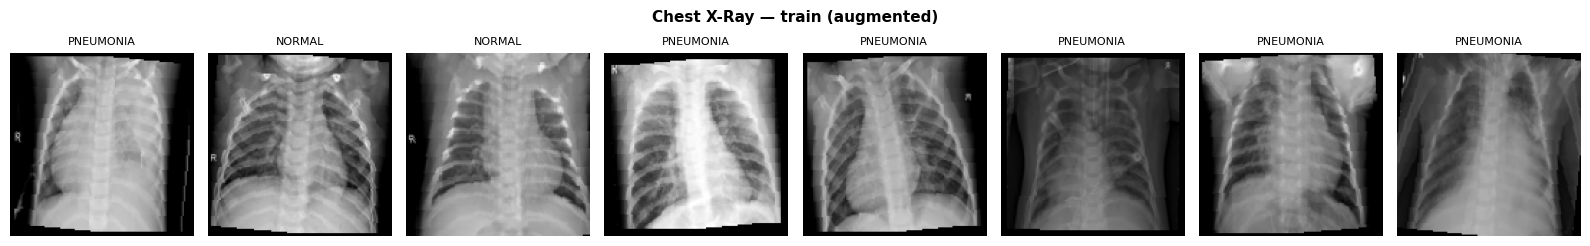

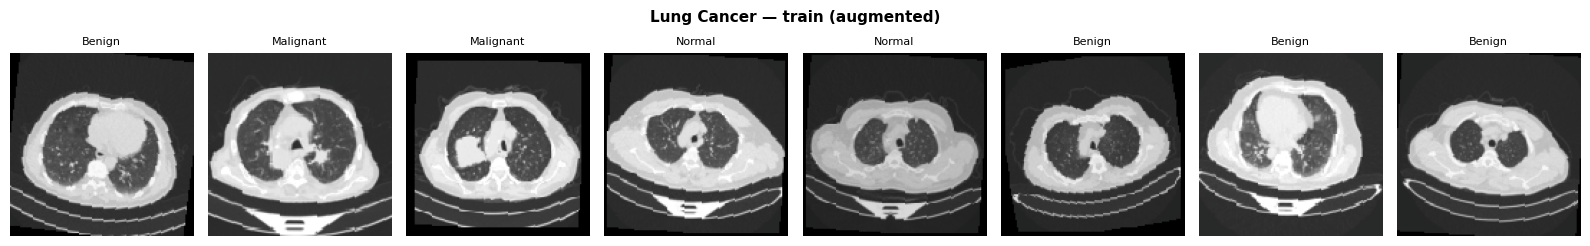

In [10]:
def plot_samples(loader, class_to_idx, title, n=8):
    idx_to_cls = {v: k for k, v in class_to_idx.items()}
    imgs, labels = next(iter(loader))
    mean = torch.tensor(IMAGENET_MEAN).view(3,1,1)
    std  = torch.tensor(IMAGENET_STD).view(3,1,1)
    imgs_d = (imgs[:n] * std + mean).clamp(0, 1)
    fig, axes = plt.subplots(1, n, figsize=(n*2, 2.5))
    fig.suptitle(title, fontsize=11, fontweight='bold')
    for i, ax in enumerate(axes):
        ax.imshow(imgs_d[i].permute(1,2,0).numpy())
        ax.set_title(idx_to_cls[labels[i].item()], fontsize=8)
        ax.axis('off')
    plt.tight_layout(); plt.show()

plot_samples(chest_train_loader, chest_classes, 'Chest X-Ray — train (augmented)')
plot_samples(lung_train_loader,  lung_classes,  'Lung Cancer — train (augmented)')

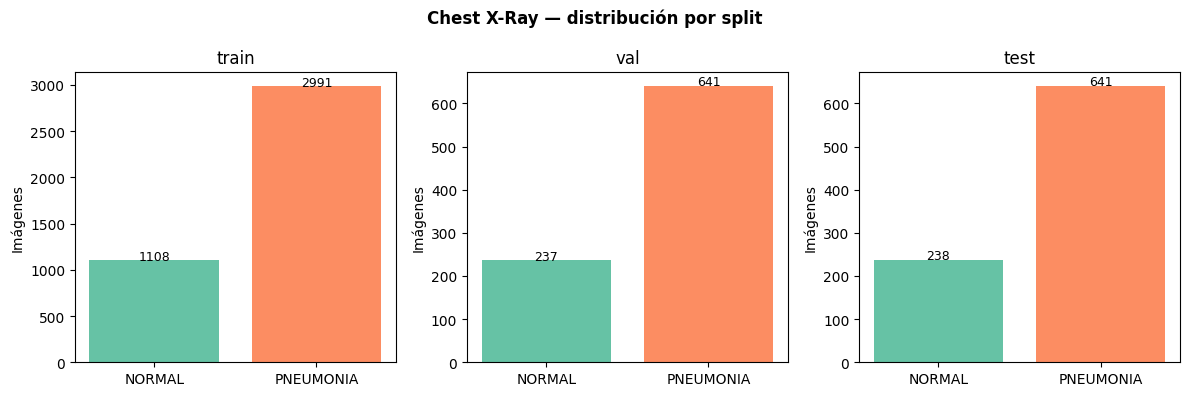

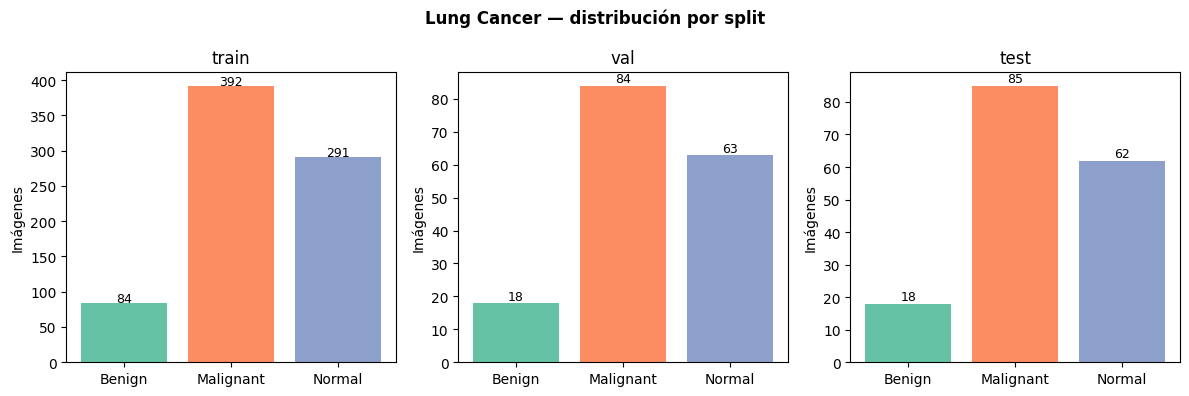

In [11]:
def plot_distribution(out_root, title):
    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    fig.suptitle(title, fontsize=12, fontweight='bold')
    for ax, split in zip(axes, ['train', 'val', 'test']):
        ds = ImageFolder(Path(out_root) / split)
        cc = Counter(ds.targets)
        lbls = [ds.classes[i] for i in sorted(cc)]
        vals = [cc[i] for i in sorted(cc)]
        bars = ax.bar(lbls, vals, color=sns.color_palette('Set2', len(lbls)))
        ax.set_title(split); ax.set_ylabel('Imágenes')
        for bar, v in zip(bars, vals):
            ax.text(bar.get_x()+bar.get_width()/2, v+1, str(v), ha='center', fontsize=9)
    plt.tight_layout(); plt.show()

plot_distribution(CHEST_OUT, 'Chest X-Ray — distribución por split')
plot_distribution(LUNG_OUT,  'Lung Cancer — distribución por split')

## 7 · Class weights para CrossEntropyLoss (IQ-OTH/NCCD)

In [12]:
def compute_class_weights(out_root):
    ds = ImageFolder(Path(out_root) / 'train')
    targets = torch.tensor(ds.targets)
    counts = torch.bincount(targets).float()
    weights = (1.0 / counts) / (1.0 / counts).sum()
    return weights, ds.classes

lung_weights, lung_class_names = compute_class_weights(LUNG_OUT)
print('Class weights IQ-OTH/NCCD (para CrossEntropyLoss):')
for cls, w in zip(lung_class_names, lung_weights):
    print(f'  {cls}: {w:.4f}')

# USO en entrenamiento (Fase 2):
#   device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
#   criterion = torch.nn.CrossEntropyLoss(weight=lung_weights.to(device))

Class weights IQ-OTH/NCCD (para CrossEntropyLoss):
  Benign: 0.6654
  Malignant: 0.1426
  Normal: 0.1921


## 8 · Resumen final

In [13]:
print('=' * 55)
print('RESUMEN ETL — Objetivo 1')
print('=' * 55)
print(f'Imagen size    : {IMG_SIZE[0]}×{IMG_SIZE[1]} px')
print(f'Normalización  : ImageNet mean/std')
print(f'Augmentation   : rot±10°, h-flip, bright±15%, zoom±10%')
print(f'Split          : 70/15/15 estratificado, seed={SEED}')
print()
for ds_name, out_root in [('Chest X-Ray', CHEST_OUT), ('Lung Cancer', LUNG_OUT)]:
    print(f'Dataset: {ds_name}')
    for split in ['train', 'val', 'test']:
        ds = ImageFolder(Path(out_root) / split)
        cc = {ds.classes[k]: v for k, v in Counter(ds.targets).items()}
        print(f'  {split:5s}: {len(ds):4d}  {cc}')
    print()
print('Listo para Fase 2 — implementación de modelos HQCNN.')

RESUMEN ETL — Objetivo 1
Imagen size    : 128×128 px
Normalización  : ImageNet mean/std
Augmentation   : rot±10°, h-flip, bright±15%, zoom±10%
Split          : 70/15/15 estratificado, seed=42

Dataset: Chest X-Ray
  train: 4099  {'NORMAL': 1108, 'PNEUMONIA': 2991}
  val  :  878  {'NORMAL': 237, 'PNEUMONIA': 641}
  test :  879  {'NORMAL': 238, 'PNEUMONIA': 641}

Dataset: Lung Cancer
  train:  767  {'Benign': 84, 'Malignant': 392, 'Normal': 291}
  val  :  165  {'Benign': 18, 'Malignant': 84, 'Normal': 63}
  test :  165  {'Benign': 18, 'Malignant': 85, 'Normal': 62}

Listo para Fase 2 — implementación de modelos HQCNN.
